## Task 1: Potential problems in linear regression
Read section 3.3.3 Potential problems in the course textbook: An Introduction to Statistical Learning with applications in Python. The section covers six common issues when fitting a linear model:

- Non-linearity of the response-predictor relationships
- Correlation of error terms
- Non-constant variance of error terms
- Outliers
- High-leverage points
- Collinearity

Structure: 
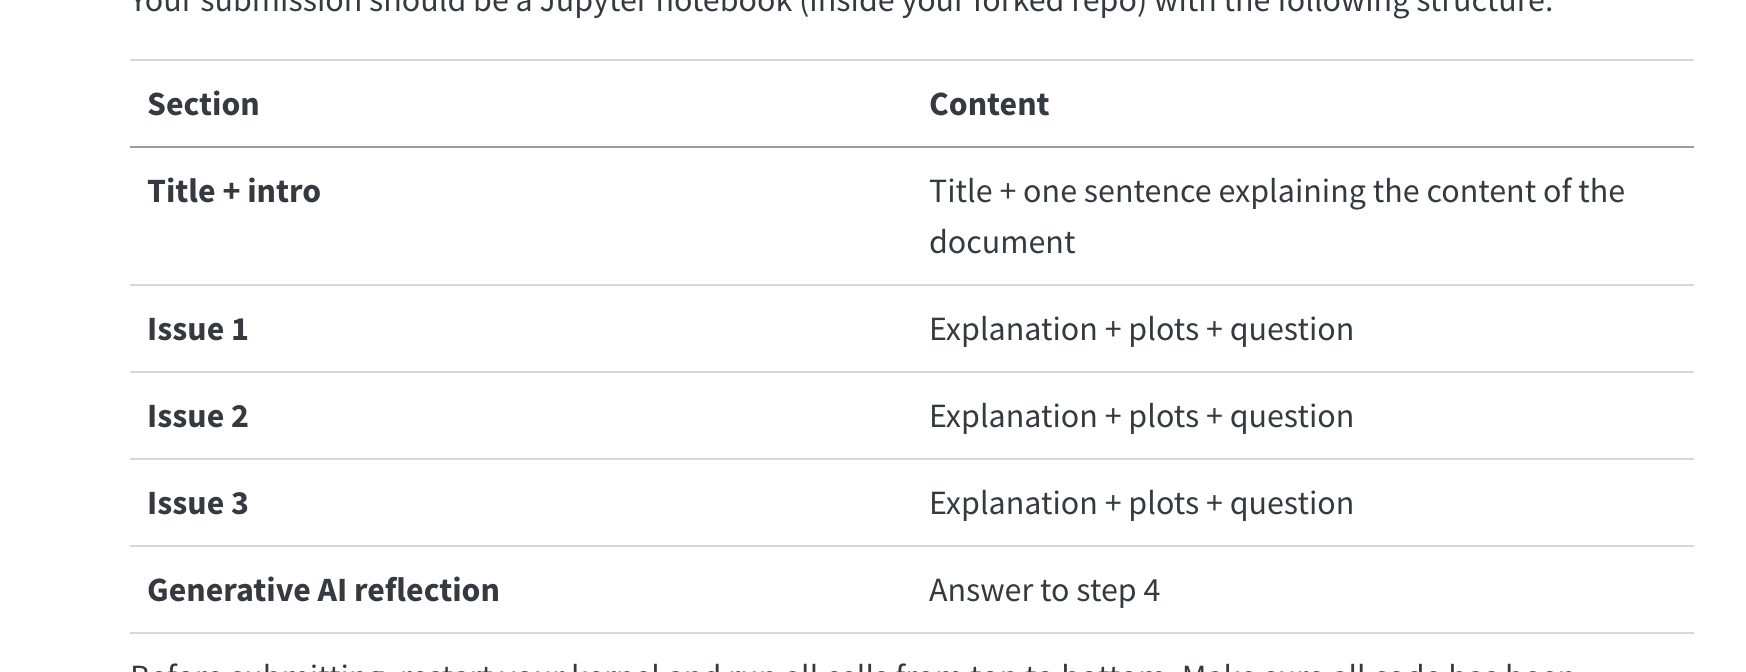

# Task 1: Potential Problems in Linear Regression
The purpose of this notebook is to determine how non-linearity of the response-predictor relationships, non-constant variance of error terms, and outliers impact 

## Non-Linearity

A linear regression model assumes that the relationship between the predictor(s) and response variable is linear (ie. must be a straight line). A non-linear relationship between the variables of interest is a significant issue for a linear regression because all conclusions drawn from the results are likely not accurate. Additionally, the prediction accuracy may be impacted/reduced, as stated in the reading. 

One way to diagnose this issue is to visualize the relationship between the predictor and its response variable. By visualizing the raw data between a single predictor and the response vairable of interest, it is much easier to visualize whether the relationship is truely linear or not. In a relationship with multiple predictors, however, it can be difficult to visualize a multi-dimensional relationship with the response variable. 

Residual plots are a better tool to visually diagnose non-linearity among the predictor(s) and response variable. In a simple linear regression (OLS), the residuals (error = distance between actual response value and predicted response value) is plotted against the predictor. In multiple linear regression, residuals are plotted against the predicted y-values. The residual plot should indicate no clear pattern if linearity truely exits in the relationship. In the event that a pattern does exist, however, then the predictor variable(s) can be transformed using log() or additional transformation methods. 

One remaining question that was not explictly addressed in the reading was: **In a multiple regression model with many predictors, if the residuals plot exhibits a non-linear pattern, how do we identify exactly which predictor is responsible for the violation (ie. which relationship is non-linear)?** To address this, I consulted Claude to create synthetic data with a hidden quadratic relationship for one predictor to demonstrate that a standard multiple linear regression will fail to capture the true underlying pattern. By plotting residuals against individual predictors, it visually isolates the specific variable causing the non-linearity; a general "Residuals vs Fitted" plot cannot capture these individual relationships alone.

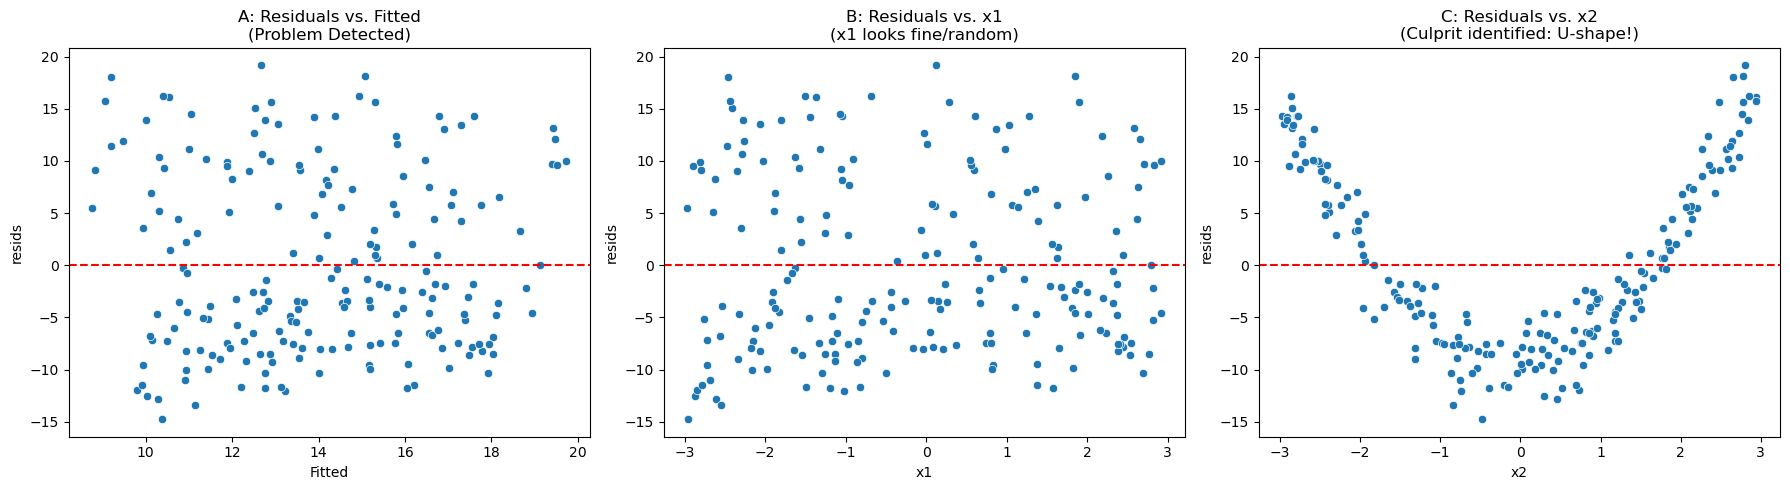

In [4]:
# Import neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Generate Synthetic Data
# x1 is linear, x2 is non-linear (quadratic)
np.random.seed(42)
n = 200
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
noise = np.random.normal(0, 2, n)

# True Relationship: y = 5 + 2*x1 + 3*(x2^2) + noise or error
y = 5 + 2*x1 + 3*(x2**2) + noise
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

# 2. Fit a standard Multiple Linear Regression (Assuming all are linear)
X = sm.add_constant(df[['x1', 'x2']])
model_linear = sm.OLS(y, X).fit()
df['resids'] = model_linear.resid

# 3. Visualization to isolate the issue
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: Residuals vs Fitted (The general warning sign)
sns.scatterplot(x=model_linear.fittedvalues, y=df['resids'], ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('A: Residuals vs. Fitted\n(Problem Detected)')
axes[0].set_xlabel("Fitted")

# B: Residuals vs x1 (Testing x1)
sns.scatterplot(x=df['x1'], y=df['resids'], ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('B: Residuals vs. x1\n(x1 looks fine/random)')

# C: Residuals vs x2 (Testing x2)
sns.scatterplot(x=df['x2'], y=df['resids'], ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('C: Residuals vs. x2\n(Culprit identified: U-shape!)')

plt.tight_layout()
plt.show()

These plots indicate how to spot non-linearity in a linear regression model. The Residuals vs. Fitted plot suggests a problem, and plotting residuals against each predictor shows that `x2` is the predictor with a curved (quadratic) relationship, indicating it needs transformation.

## Non-Constant Variance of Error Terms
Non-constant variance, also known as heteroscedasticity, occurs when the spread of the residuals changes across the range of predictor values. This violates the linear regression assumption that error terms must have uniform variance across all values of the predictor; this is known as homoscedasticity Heteroscedasticity is a serious issue because standard errors, confidence intervals, and hypothesis tests all depend on the constant-variance assumption. As such, violating this assumption can cause these quantities to become unreliable. 

Homogeneity of variance can be visualized by plotting residuals against fitted values. As stated in the reading, a funnel shape (spread of residuals increases or decreases systematically) is a sign of heteroscedacity. A concave transformation can be applied to the response, such as log(Y) or sqrt(Y). These transformations compress large values more than small ones, ultimately reducing the growing spread and maintains constant variance. 

In a simple linear regression model, how can one detect heteroscedasticity in the residuals, and how does a log transformation of the response help correct it? To illustrate this, I employed Claude to generate synthetic data where the error variance increases with x to create a funnel shaped spread. The code fits linear models to both the original y and log(y), and then creates three plotted panels: the raw data, the residuals showing the funnel pattern, and the residuals after the log transformation where the funnel disappears. 


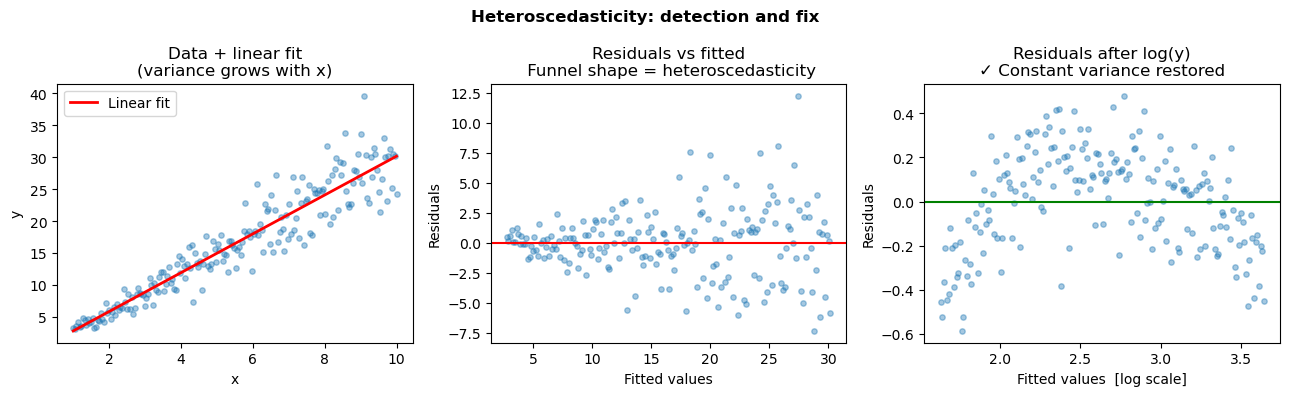

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

x = np.linspace(1, 10, n)
y = 3 * x + np.random.normal(0, 0.5 * x, n)

# Fit on original y
coef = np.polyfit(x, y, 1)
y_hat = np.polyval(coef, x)
residuals = y - y_hat

# Fit on log(y)
log_y = np.log(y)
coef_log = np.polyfit(x, log_y, 1)
log_y_hat = np.polyval(coef_log, x)
residuals_log = log_y - log_y_hat

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Heteroscedasticity: detection and fix', fontweight='bold')

axes[0].scatter(x, y, alpha=0.4, s=15)
axes[0].plot(x, y_hat, color='red', lw=2, label='Linear fit')
axes[0].set_title('Data + linear fit\n(variance grows with x)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].scatter(y_hat, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color='red', lw=1.5)
axes[1].set_title('Residuals vs fitted\n Funnel shape = heteroscedasticity')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

axes[2].scatter(log_y_hat, residuals_log, alpha=0.4, s=15)
axes[2].axhline(0, color='green', lw=1.5)
axes[2].set_title('Residuals after log(y)\n✓ Constant variance restored')
axes[2].set_xlabel('Fitted values  [log scale]')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

The succession of plots demonstrate heteroscedasticity by generating a dataset where the error variance expands as the predictor increases, creating a diagnostic "funnel shape" in the initial residual plot. To address this, a log transformation is applied to the response variable, enabling constant spread of residuals across the fitted values; the funnel shape is eliminated. However, there is clear non-linearity following the transformation of the response variable, as indicated by the defined U-shape in the third panel. 

## Outliers
2. Select 3 of the issues above and, for each one, write:

- a short paragraph explaining what the problem is, why it matters, and how to detect it (and how to address it, if applicable)





**outliers**

- a question that came up while reading that you couldn’t answer from the text alone, and the answer you investigated


Add a brief caption (2-3 sentences) describiing what the plots show, or integrate this explanation into your paragraph from step 2.

In a short paragraph (4–6 sentences), reflect on your use of generative AI in this task: which tool did you use, what prompts did you give it, and how many iterations did it take to get working code? Note any mistakes the AI made and how you identified and fixed them.
